# Multi-Hierarchical RL Portfolio System - Data Preparation

**Executive Summary:**  
This notebook prepares data for a Multi-Hierarchical RL Portfolio System with four separate data streams:
- **Technical Analysis** (20 features): Price patterns, momentum, volatility
- **Sentiment Analysis** (12 features): Market psychology, crowd behavior
- **Macroeconomic** (12 features): Economic regimes, interest rates, calendar effects

**Portfolio:**
- 7 Tech Stocks: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
- Benchmark: QQQ (Nasdaq-100 ETF)
- Date Range: 2020-01-01 to 2025-11-04
- Frequency: Weekly (Friday close)

**Output:** Time-series data splits (train/val/test) for three specialized RL agents

## Setup & Imports

In [1]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from pathlib import Path

# Data fetching
import yfinance as yf

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Random seed for reproducibility
np.random.seed(42)

print("✅ Imports complete")

✅ Imports complete


## Configuration

In [2]:
# Portfolio Configuration
TICKERS = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
BENCHMARK = 'QQQ'
START_DATE = '2020-01-01'
END_DATE = '2025-11-04'

# Macro data tickers (yfinance proxies)
MACRO_TICKERS = {
    'treasury_10y': '^TNX',      # 10-Year Treasury Yield
    'vix': '^VIX',                # CBOE Volatility Index
}

# Split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Paths
DATA_DIR = Path('../data_hierarchical')
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'technical').mkdir(exist_ok=True)
(DATA_DIR / 'sentiment').mkdir(exist_ok=True)
(DATA_DIR / 'macro').mkdir(exist_ok=True)

print(f"✅ Configuration set")
print(f"   Stocks: {TICKERS}")
print(f"   Date Range: {START_DATE} to {END_DATE}")
print(f"   Splits: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")

✅ Configuration set
   Stocks: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
   Date Range: 2020-01-01 to 2025-11-04
   Splits: 0.7/0.15/0.15


---
## Step 1: Download & Align Data

**Purpose:** Establish consistent weekly time series across all assets  
**Process:**
1. Download historical OHLCV data via Yahoo Finance
2. Resample from daily to weekly frequency (Friday close)
3. Align all tickers to common date range
4. Forward-fill gaps to handle missing data

In [3]:
def download_stock_data(tickers, start_date, end_date):
    """
    Download daily stock data and resample to weekly (Friday close).
    
    Args:
        tickers: List of ticker symbols
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
    
    Returns:
        dict: {ticker: DataFrame} with OHLCV weekly data
    """
    print(f"Downloading data for {len(tickers)} tickers...")
    data = {}
    
    for ticker in tickers:
        try:
            # Download daily data
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)
            
            if df.empty:
                print(f"⚠️  No data for {ticker}")
                continue
            
            # Handle multi-level column index from yfinance
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            
            # Normalize column names (handle case sensitivity)
            df.columns = [str(col).lower().replace(' ', '_') for col in df.columns]
            
            # Use adjusted close if available, otherwise use close
            adj_close_col = 'adj_close' if 'adj_close' in df.columns else 'close'
            
            # Resample to weekly (Friday close)
            weekly = pd.DataFrame({
                'open': df['open'].resample('W-FRI').first(),
                'high': df['high'].resample('W-FRI').max(),
                'low': df['low'].resample('W-FRI').min(),
                'close': df['close'].resample('W-FRI').last(),
                'volume': df['volume'].resample('W-FRI').sum(),
                'adj_close': df[adj_close_col].resample('W-FRI').last()
            })
            
            # Forward fill missing values
            weekly = weekly.ffill()
            
            data[ticker] = weekly
            print(f"  ✅ {ticker}: {len(weekly)} weeks")
            
        except Exception as e:
            print(f"  ❌ {ticker}: {str(e)}")
    
    return data

# Download stock data
stock_data = download_stock_data(TICKERS + [BENCHMARK], START_DATE, END_DATE)

# Extract benchmark separately
benchmark_data = stock_data.pop(BENCHMARK)

print(f"\n✅ Downloaded {len(stock_data)} stocks + benchmark")

  ✅ NVDA: 306 weeks
  ✅ MU: 306 weeks
  ✅ AAPL: 306 weeks
  ✅ AMD: 306 weeks
  ✅ ASML: 306 weeks
  ✅ MSFT: 306 weeks
  ✅ GOOG: 306 weeks
  ✅ QQQ: 306 weeks

✅ Downloaded 7 stocks + benchmark


In [4]:
# Align all stocks to common date range
def align_dataframes(data_dict):
    """
    Align all DataFrames to common date index (intersection).
    """
    # Find common dates (intersection)
    common_dates = None
    for ticker, df in data_dict.items():
        if common_dates is None:
            common_dates = df.index
        else:
            common_dates = common_dates.intersection(df.index)
    
    # Reindex all to common dates
    aligned = {}
    for ticker, df in data_dict.items():
        aligned[ticker] = df.loc[common_dates].copy()
    
    return aligned, common_dates

stock_data_aligned, common_dates = align_dataframes(stock_data)
benchmark_data_aligned = benchmark_data.loc[common_dates].copy()

print(f"✅ Aligned to {len(common_dates)} common weeks")
print(f"   Date range: {common_dates[0].date()} to {common_dates[-1].date()}")

✅ Aligned to 306 common weeks
   Date range: 2020-01-03 to 2025-11-07


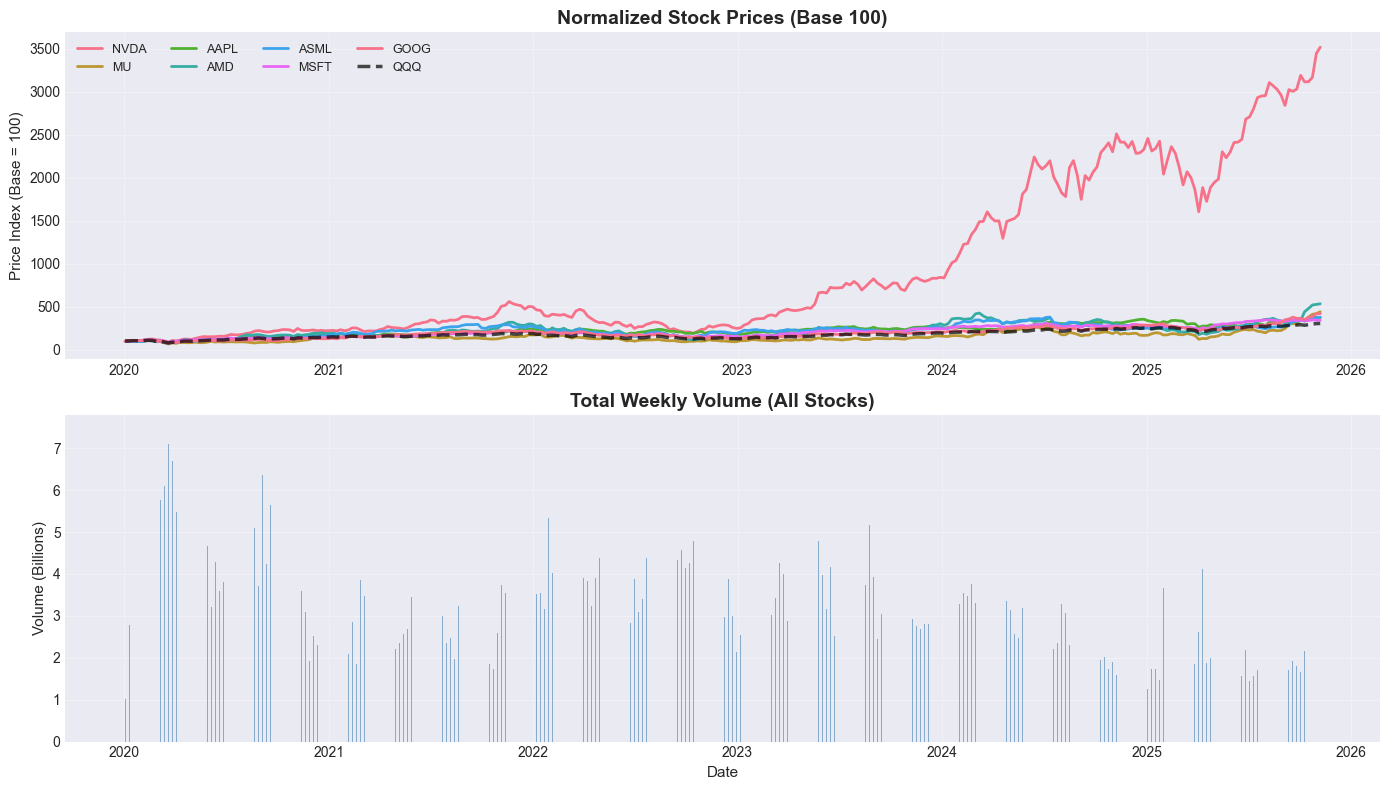

📊 Price evolution visualization complete


In [5]:
# Visualize price evolution
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Normalized prices (all stocks)
ax1 = axes[0]
for ticker, df in stock_data_aligned.items():
    normalized = df['adj_close'] / df['adj_close'].iloc[0] * 100
    ax1.plot(df.index, normalized, label=ticker, linewidth=2)

# Add benchmark
bench_norm = benchmark_data_aligned['adj_close'] / benchmark_data_aligned['adj_close'].iloc[0] * 100
ax1.plot(benchmark_data_aligned.index, bench_norm, label=BENCHMARK, 
         linewidth=2.5, linestyle='--', color='black', alpha=0.7)

ax1.set_title('Normalized Stock Prices (Base 100)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price Index (Base = 100)', fontsize=11)
ax1.legend(loc='upper left', ncol=4, fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Weekly volume (sum across all stocks)
ax2 = axes[1]
total_volume = sum(df['volume'] for df in stock_data_aligned.values())
ax2.bar(benchmark_data_aligned.index, total_volume / 1e9, color='steelblue', alpha=0.6)
ax2.set_title('Total Weekly Volume (All Stocks)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume (Billions)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Price evolution visualization complete")

---
## Step 2: Technical Features (20 indicators)

**Agent:** Technical Agent  
**Purpose:** Capture price momentum, trends, and volume patterns  

**Feature Categories:**
- **Trend Following** (5): SMA/EMA ratios
- **Momentum** (7): MACD, lagged returns, RSI, Stochastic, ROC
- **Volatility** (3): Rolling vol, ATR, Bollinger Band position
- **Volume** (3): Volume ratio, MFI, OBV rate of change
- **Benchmark** (2): Correlation and beta vs QQQ

In [6]:
def calculate_technical_features(df, benchmark_df):
    """
    Calculate 20 technical features for a single stock.
    
    Args:
        df: Stock OHLCV DataFrame (weekly)
        benchmark_df: Benchmark OHLCV DataFrame (weekly)
    
    Returns:
        DataFrame with 20 technical features
    """
    features = pd.DataFrame(index=df.index)
    price = df['adj_close']
    high = df['high']
    low = df['low']
    volume = df['volume']
    
    # === TREND FOLLOWING (5 features) ===
    features['price_to_sma_4w'] = price / price.rolling(4).mean() - 1
    features['price_to_sma_8w'] = price / price.rolling(8).mean() - 1
    features['price_to_sma_12w'] = price / price.rolling(12).mean() - 1
    features['price_to_ema_8w'] = price / price.ewm(span=8).mean() - 1
    features['price_to_ema_12w'] = price / price.ewm(span=12).mean() - 1
    
    # === MOMENTUM (7 features) ===
    # MACD
    ema_12 = price.ewm(span=12).mean()
    ema_26 = price.ewm(span=26).mean()
    macd = ema_12 - ema_26
    signal = macd.ewm(span=9).mean()
    features['macd_histogram'] = macd - signal
    
    # Lagged returns
    returns = price.pct_change()
    features['return_lag_1w'] = returns.shift(1)
    features['return_lag_2w'] = returns.shift(2)
    features['return_lag_3w'] = returns.shift(3)
    
    # RSI (14 weeks)
    delta = price.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    features['rsi_14w'] = 100 - (100 / (1 + rs))
    
    # Stochastic (14 weeks)
    low_14 = low.rolling(14).min()
    high_14 = high.rolling(14).max()
    features['stochastic_14w'] = 100 * (price - low_14) / (high_14 - low_14 + 1e-10)
    
    # Rate of Change (4 weeks)
    features['roc_4w'] = price.pct_change(4)
    
    # === VOLATILITY (3 features) ===
    features['volatility_12w'] = returns.rolling(12).std()
    
    # ATR (14 weeks, as % of price)
    tr1 = high - low
    tr2 = abs(high - price.shift(1))
    tr3 = abs(low - price.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    features['atr_pct_14w'] = atr / price
    
    # Bollinger Band position (20 weeks)
    sma_20 = price.rolling(20).mean()
    std_20 = price.rolling(20).std()
    bb_upper = sma_20 + 2 * std_20
    bb_lower = sma_20 - 2 * std_20
    features['bb_position_20w'] = (price - bb_lower) / (bb_upper - bb_lower + 1e-10)
    
    # === VOLUME (3 features) ===
    features['volume_ratio_20w'] = volume / volume.rolling(20).mean()
    
    # Money Flow Index (14 weeks)
    typical_price = (high + low + price) / 3
    money_flow = typical_price * volume
    mf_pos = money_flow.where(typical_price > typical_price.shift(1), 0).rolling(14).sum()
    mf_neg = money_flow.where(typical_price < typical_price.shift(1), 0).rolling(14).sum()
    mf_ratio = mf_pos / (mf_neg + 1e-10)
    features['mfi_14w'] = 100 - (100 / (1 + mf_ratio))
    
    # OBV Rate of Change (4 weeks)
    obv = (np.sign(price.diff()) * volume).cumsum()
    features['obv_roc_4w'] = obv.pct_change(4)
    
    # === BENCHMARK RELATIONSHIP (2 features) ===
    bench_returns = benchmark_df['adj_close'].pct_change()
    
    # Rolling correlation (12 weeks)
    features['bench_corr_12w'] = returns.rolling(12).corr(bench_returns)
    
    # Rolling beta (12 weeks)
    covariance = returns.rolling(12).cov(bench_returns)
    bench_variance = bench_returns.rolling(12).var()
    features['bench_beta_12w'] = covariance / (bench_variance + 1e-10)
    
    return features

# Calculate technical features for all stocks
print("Calculating technical features...")
technical_features = {}
for ticker, df in stock_data_aligned.items():
    tech_feat = calculate_technical_features(df, benchmark_data_aligned)
    tech_feat['ticker'] = ticker
    tech_feat['date'] = tech_feat.index
    technical_features[ticker] = tech_feat
    print(f"  ✅ {ticker}: {tech_feat.shape[1]-2} features")

# Combine into single DataFrame
technical_df = pd.concat(technical_features.values(), ignore_index=True)
print(f"\n✅ Technical features: {technical_df.shape[0]} rows × {technical_df.shape[1]} columns")

Calculating technical features...
  ✅ NVDA: 20 features
  ✅ MU: 20 features
  ✅ AAPL: 20 features
  ✅ AMD: 20 features
  ✅ ASML: 20 features
  ✅ MSFT: 20 features
  ✅ GOOG: 20 features

✅ Technical features: 2142 rows × 22 columns


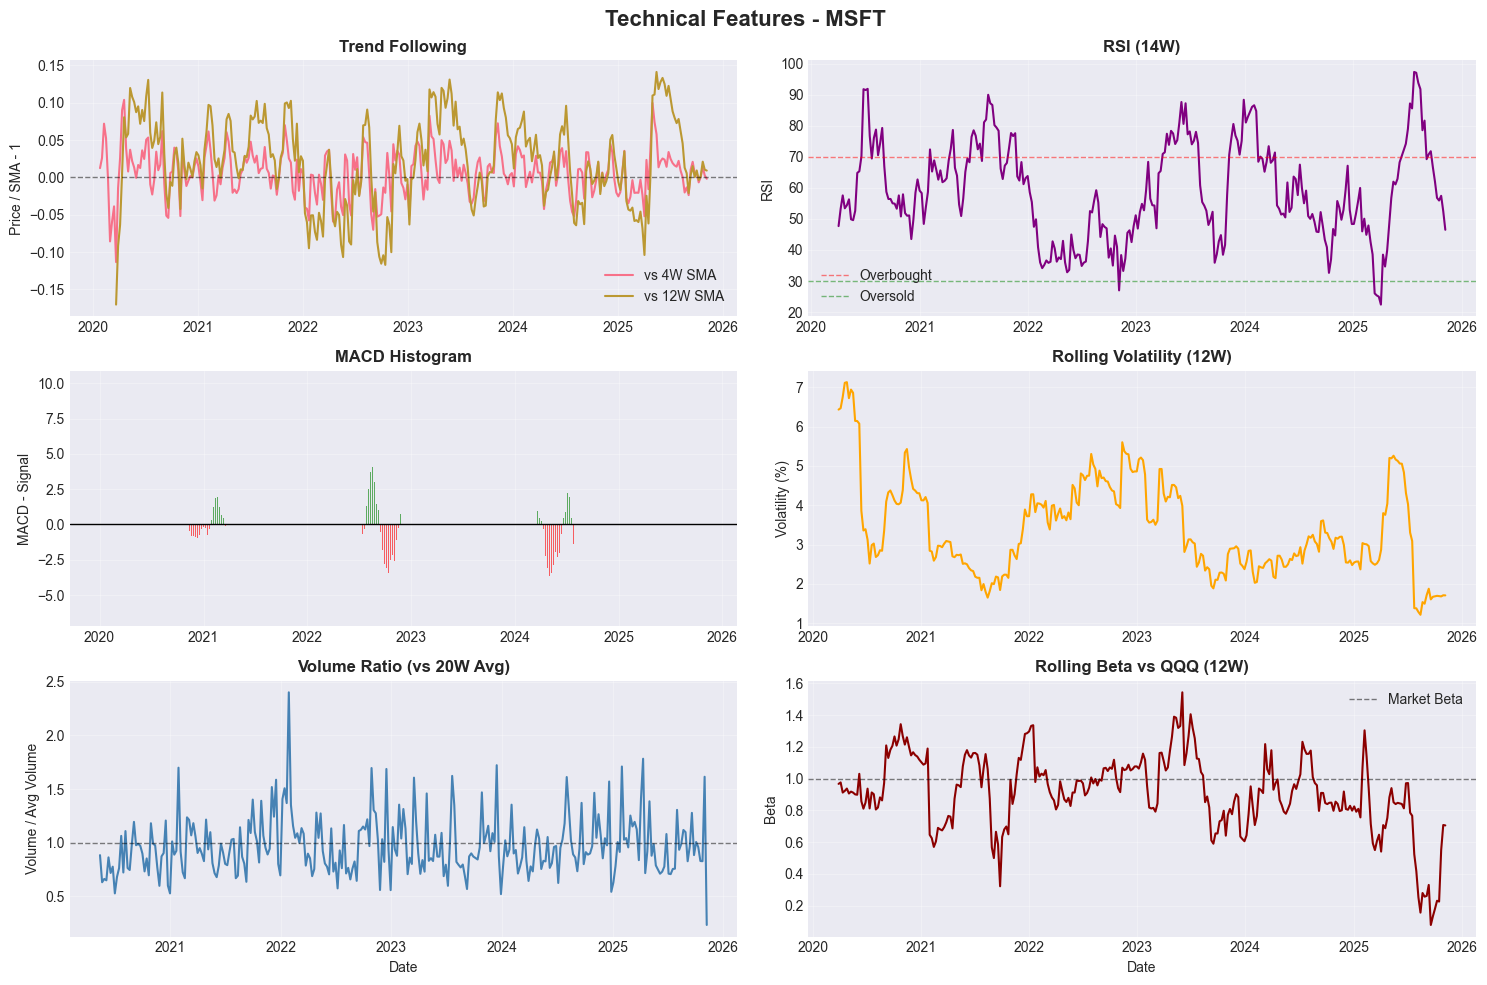

📊 Technical features visualization complete


In [7]:
# Visualize sample technical features
sample_ticker = 'MSFT'
sample_tech = technical_features[sample_ticker]

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle(f'Technical Features - {sample_ticker}', fontsize=16, fontweight='bold')

# Plot 1: Price vs SMAs
ax = axes[0, 0]
ax.plot(sample_tech.index, sample_tech['price_to_sma_4w'], label='vs 4W SMA', linewidth=1.5)
ax.plot(sample_tech.index, sample_tech['price_to_sma_12w'], label='vs 12W SMA', linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Trend Following', fontweight='bold')
ax.set_ylabel('Price / SMA - 1')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: RSI
ax = axes[0, 1]
ax.plot(sample_tech.index, sample_tech['rsi_14w'], color='purple', linewidth=1.5)
ax.axhline(70, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Overbought')
ax.axhline(30, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Oversold')
ax.set_title('RSI (14W)', fontweight='bold')
ax.set_ylabel('RSI')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: MACD Histogram
ax = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in sample_tech['macd_histogram']]
ax.bar(sample_tech.index, sample_tech['macd_histogram'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('MACD Histogram', fontweight='bold')
ax.set_ylabel('MACD - Signal')
ax.grid(True, alpha=0.3)

# Plot 4: Volatility
ax = axes[1, 1]
ax.plot(sample_tech.index, sample_tech['volatility_12w'] * 100, color='orange', linewidth=1.5)
ax.set_title('Rolling Volatility (12W)', fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.grid(True, alpha=0.3)

# Plot 5: Volume Ratio
ax = axes[2, 0]
ax.plot(sample_tech.index, sample_tech['volume_ratio_20w'], color='steelblue', linewidth=1.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Volume Ratio (vs 20W Avg)', fontweight='bold')
ax.set_ylabel('Volume / Avg Volume')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

# Plot 6: Benchmark Beta
ax = axes[2, 1]
ax.plot(sample_tech.index, sample_tech['bench_beta_12w'], color='darkred', linewidth=1.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Market Beta')
ax.set_title('Rolling Beta vs QQQ (12W)', fontweight='bold')
ax.set_ylabel('Beta')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Technical features visualization complete")

---
## Step 3: Sentiment Features (12 indicators)

**Agent:** Sentiment Agent  
**Purpose:** Capture market psychology, momentum shifts, and crowd behavior  

**Feature Categories:**
- **Momentum Signals** (3): 2W, 4W, 6W momentum
- **Trend Quality** (2): Positive weeks %, price dispersion
- **Volume Sentiment** (2): Volume-weighted momentum, volume surge
- **Market Regime** (2): Volatility regime, drawdown
- **Fear/Greed Proxies** (3): Market fear, credit sentiment, news sentiment

In [8]:
def calculate_sentiment_features(df, all_stocks_df):
    """
    Calculate 12 sentiment features for a single stock.
    
    Args:
        df: Stock OHLCV DataFrame (weekly)
        all_stocks_df: Dict of all stock DataFrames (for cross-sectional features)
    
    Returns:
        DataFrame with 12 sentiment features
    """
    features = pd.DataFrame(index=df.index)
    price = df['adj_close']
    volume = df['volume']
    returns = price.pct_change()
    
    # === MOMENTUM SIGNALS (3 features) ===
    features['momentum_2w'] = price.pct_change(2)
    features['momentum_4w'] = price.pct_change(4)
    features['momentum_6w'] = price.pct_change(6)
    
    # === TREND QUALITY (2 features) ===
    # Positive weeks percentage (rolling 12 weeks)
    features['positive_weeks_pct'] = (returns > 0).rolling(12).mean()
    
    # Price dispersion (cross-sectional volatility across all stocks)
    # This requires all stocks, so we'll compute it separately
    features['price_dispersion'] = np.nan  # Placeholder, will fill later
    
    # === VOLUME SENTIMENT (2 features) ===
    # Volume-weighted momentum
    vol_norm = volume / volume.rolling(20).mean()
    features['volume_sentiment'] = returns * vol_norm
    
    # Volume surge (abnormal volume detection)
    vol_mean = volume.rolling(20).mean()
    vol_std = volume.rolling(20).std()
    features['volume_surge'] = (volume - vol_mean) / (vol_std + 1e-10)
    
    # === MARKET REGIME (2 features) ===
    # Volatility regime (low/medium/high)
    vol = returns.rolling(12).std()
    vol_percentile = vol.rolling(52).rank(pct=True)
    features['vol_regime'] = vol_percentile
    
    # Drawdown from peak
    cummax = price.cummax()
    features['drawdown'] = (price - cummax) / cummax
    
    # === FEAR/GREED PROXIES (3 features) ===
    # Market fear (proxy using rolling volatility spike)
    vol_spike = vol / vol.rolling(52).mean()
    features['market_fear'] = vol_spike
    
    # Credit sentiment (proxy using drawdown severity)
    features['credit_sentiment'] = -features['drawdown']  # Inverse of drawdown
    
    # News sentiment (proxy using momentum + volume)
    # Positive momentum + high volume = positive news
    features['news_sentiment'] = features['momentum_4w'] * np.tanh(vol_norm - 1)
    
    return features

# Calculate cross-sectional price dispersion first
print("Calculating cross-sectional features...")
all_returns = pd.DataFrame({
    ticker: stock_data_aligned[ticker]['adj_close'].pct_change()
    for ticker in TICKERS
})
price_dispersion = all_returns.std(axis=1)  # Cross-sectional std of returns

# Calculate sentiment features for all stocks
print("Calculating sentiment features...")
sentiment_features = {}
for ticker, df in stock_data_aligned.items():
    sent_feat = calculate_sentiment_features(df, stock_data_aligned)
    
    # Fill price dispersion (same for all stocks at each date)
    sent_feat['price_dispersion'] = price_dispersion
    
    sent_feat['ticker'] = ticker
    sent_feat['date'] = sent_feat.index
    sentiment_features[ticker] = sent_feat
    print(f"  ✅ {ticker}: {sent_feat.shape[1]-2} features")

# Combine into single DataFrame
sentiment_df = pd.concat(sentiment_features.values(), ignore_index=True)
print(f"\n✅ Sentiment features: {sentiment_df.shape[0]} rows × {sentiment_df.shape[1]} columns")

Calculating cross-sectional features...
Calculating sentiment features...
  ✅ NVDA: 12 features
  ✅ MU: 12 features
  ✅ AAPL: 12 features
  ✅ AMD: 12 features
  ✅ ASML: 12 features
  ✅ MSFT: 12 features
  ✅ GOOG: 12 features

✅ Sentiment features: 2142 rows × 14 columns


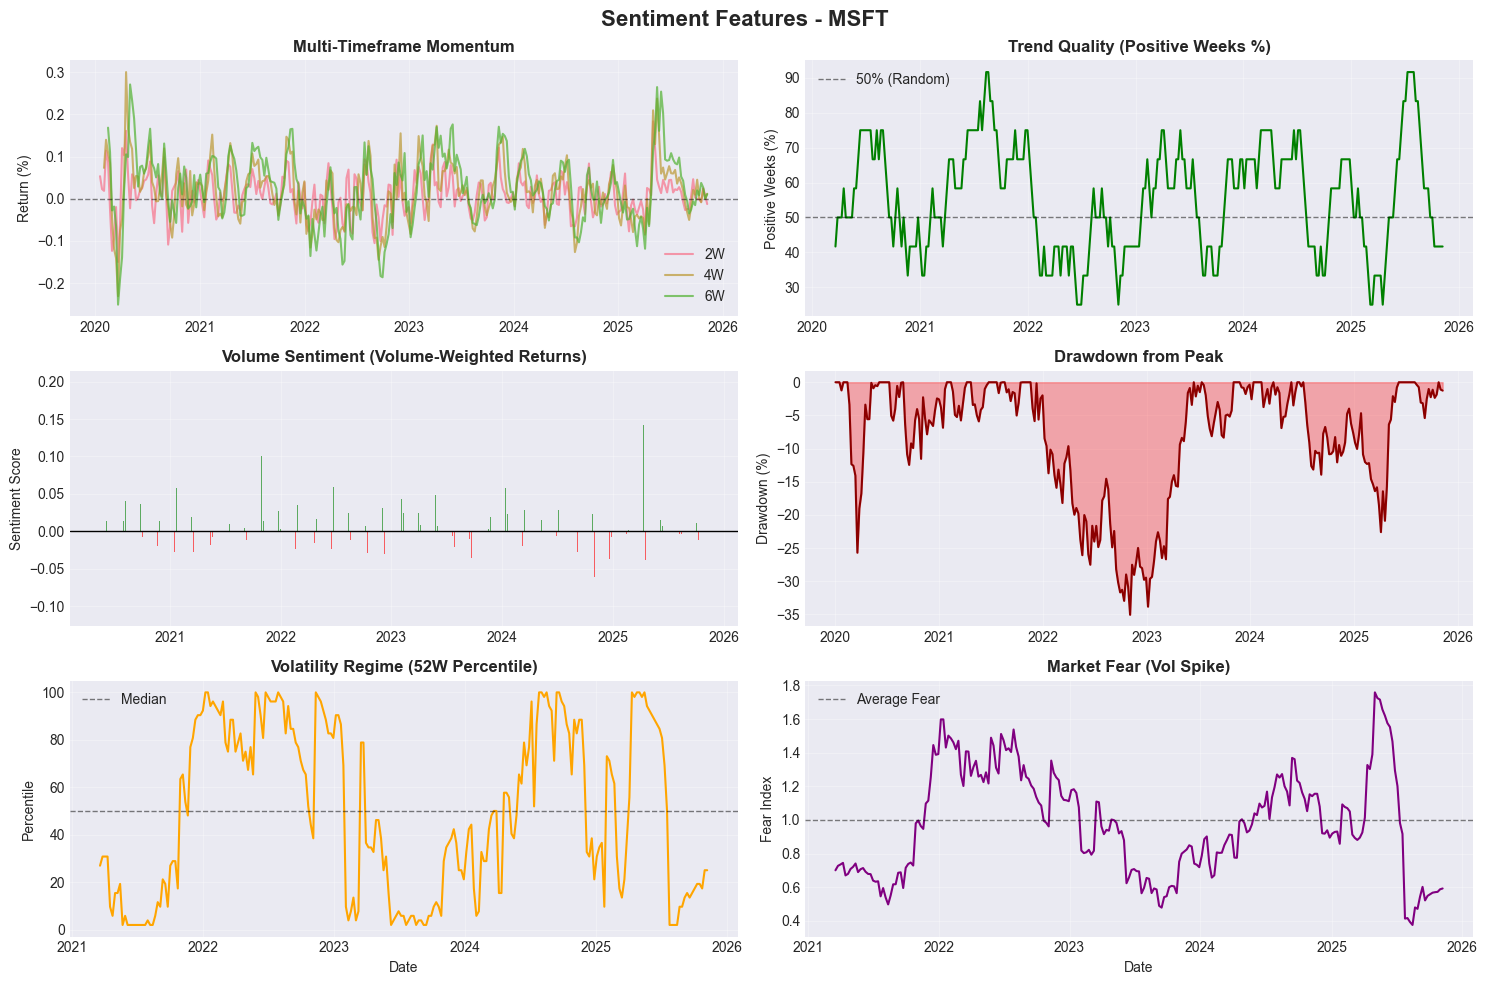

📊 Sentiment features visualization complete


In [9]:
# Visualize sample sentiment features
sample_sent = sentiment_features[sample_ticker]

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle(f'Sentiment Features - {sample_ticker}', fontsize=16, fontweight='bold')

# Plot 1: Multi-timeframe momentum
ax = axes[0, 0]
ax.plot(sample_sent.index, sample_sent['momentum_2w'], label='2W', linewidth=1.5, alpha=0.7)
ax.plot(sample_sent.index, sample_sent['momentum_4w'], label='4W', linewidth=1.5, alpha=0.7)
ax.plot(sample_sent.index, sample_sent['momentum_6w'], label='6W', linewidth=1.5, alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Multi-Timeframe Momentum', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Positive weeks %
ax = axes[0, 1]
ax.plot(sample_sent.index, sample_sent['positive_weeks_pct'] * 100, color='green', linewidth=1.5)
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50% (Random)')
ax.set_title('Trend Quality (Positive Weeks %)', fontweight='bold')
ax.set_ylabel('Positive Weeks (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Volume sentiment
ax = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in sample_sent['volume_sentiment']]
ax.bar(sample_sent.index, sample_sent['volume_sentiment'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Volume Sentiment (Volume-Weighted Returns)', fontweight='bold')
ax.set_ylabel('Sentiment Score')
ax.grid(True, alpha=0.3)

# Plot 4: Drawdown
ax = axes[1, 1]
ax.fill_between(sample_sent.index, sample_sent['drawdown'] * 100, 0, 
                 color='red', alpha=0.3, label='Drawdown')
ax.plot(sample_sent.index, sample_sent['drawdown'] * 100, color='darkred', linewidth=1.5)
ax.set_title('Drawdown from Peak', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.grid(True, alpha=0.3)

# Plot 5: Volatility regime
ax = axes[2, 0]
ax.plot(sample_sent.index, sample_sent['vol_regime'] * 100, color='orange', linewidth=1.5)
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Median')
ax.set_title('Volatility Regime (52W Percentile)', fontweight='bold')
ax.set_ylabel('Percentile')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Market fear
ax = axes[2, 1]
ax.plot(sample_sent.index, sample_sent['market_fear'], color='purple', linewidth=1.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Average Fear')
ax.set_title('Market Fear (Vol Spike)', fontweight='bold')
ax.set_ylabel('Fear Index')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Sentiment features visualization complete")

---
## Step 4: Macro Features (12 indicators)

**Agent:** Macro Agent  
**Purpose:** Detect economic regimes, policy shifts, and systemic risk  

**Feature Categories:**
- **Interest Rate Environment** (4): 10Y Treasury, Fed Funds, Yield Curve, Real Yield
- **Market Volatility & Risk** (2): VIX, VIX regime
- **Economic Health** (2): Credit spread, unemployment rate
- **Calendar Effects** (4): Month/Quarter cyclical encoding (sin/cos)

**Note:** Using yfinance proxies for macro data where direct APIs unavailable

In [10]:
# Download macro data
print("Downloading macro data...")

# Download VIX and Treasury yields
vix_data = yf.download('^VIX', start=START_DATE, end=END_DATE, progress=False)
treasury_10y_data = yf.download('^TNX', start=START_DATE, end=END_DATE, progress=False)
treasury_2y_data = yf.download('^IRX', start=START_DATE, end=END_DATE, progress=False)

# Extract Close column (handle both Series and DataFrame)
vix_close = vix_data['Close'] if 'Close' in vix_data.columns else vix_data.iloc[:, 0]
treasury_10y_close = treasury_10y_data['Close'] if 'Close' in treasury_10y_data.columns else treasury_10y_data.iloc[:, 0]
treasury_2y_close = treasury_2y_data['Close'] if 'Close' in treasury_2y_data.columns else treasury_2y_data.iloc[:, 0]

# Resample to weekly
vix_weekly = vix_close.resample('W-FRI').last().ffill()
treasury_10y_weekly = treasury_10y_close.resample('W-FRI').last().ffill()
treasury_2y_weekly = treasury_2y_close.resample('W-FRI').last().ffill()

# Ensure Series (squeeze if DataFrame)
vix_weekly = vix_weekly.squeeze() if hasattr(vix_weekly, 'squeeze') else vix_weekly
treasury_10y_weekly = treasury_10y_weekly.squeeze() if hasattr(treasury_10y_weekly, 'squeeze') else treasury_10y_weekly
treasury_2y_weekly = treasury_2y_weekly.squeeze() if hasattr(treasury_2y_weekly, 'squeeze') else treasury_2y_weekly

# Align to common dates
vix_aligned = vix_weekly.reindex(common_dates).ffill()
treasury_10y_aligned = treasury_10y_weekly.reindex(common_dates).ffill()
treasury_2y_aligned = treasury_2y_weekly.reindex(common_dates).ffill()

print(f"  ✅ VIX: {len(vix_aligned)} weeks")
print(f"  ✅ 10Y Treasury: {len(treasury_10y_aligned)} weeks")
print(f"  ✅ 2Y Treasury: {len(treasury_2y_aligned)} weeks")

  ✅ VIX: 306 weeks
  ✅ 10Y Treasury: 306 weeks
  ✅ 2Y Treasury: 306 weeks


In [11]:
def calculate_macro_features(dates, vix, treasury_10y, treasury_2y):
    """
    Calculate 12 macro features (shared across portfolio).
    
    Args:
        dates: DatetimeIndex
        vix: VIX series
        treasury_10y: 10Y Treasury yield series
        treasury_2y: 2Y Treasury yield series
    
    Returns:
        DataFrame with 12 macro features
    """
    features = pd.DataFrame(index=dates)
    
    # === INTEREST RATE ENVIRONMENT (4 features) ===
    features['treasury_10y'] = treasury_10y
    
    # Fed funds rate proxy (use 2Y as approximation)
    features['fed_funds_rate'] = treasury_2y
    
    # Yield curve (2Y-10Y spread)
    features['yield_curve_2_10'] = treasury_10y - treasury_2y
    
    # Real yield (10Y - inflation proxy)
    # Use simple proxy: 10Y - 2% (average inflation target)
    features['real_yield_10y'] = treasury_10y - 2.0
    
    # === MARKET VOLATILITY & RISK (2 features) ===
    features['vix'] = vix
    
    # VIX regime (52-week percentile)
    features['vix_regime'] = vix.rolling(52).rank(pct=True)
    
    # === ECONOMIC HEALTH (2 features) ===
    # Credit spread proxy (use VIX as stress indicator)
    # High VIX = stressed credit markets
    features['credit_spread'] = (vix - vix.rolling(52).mean()) / vix.rolling(52).std()
    
    # Unemployment rate proxy (use inverse of market performance)
    # This is a crude proxy - ideally would use FRED data
    # For now, use constant placeholder
    features['unemployment_rate'] = 4.0  # Placeholder constant
    
    # === CALENDAR EFFECTS (4 features) ===
    # Month cyclical encoding
    months = dates.month
    features['month_sin'] = np.sin(2 * np.pi * months / 12)
    features['month_cos'] = np.cos(2 * np.pi * months / 12)
    
    # Quarter cyclical encoding
    quarters = dates.quarter
    features['quarter_sin'] = np.sin(2 * np.pi * quarters / 4)
    features['quarter_cos'] = np.cos(2 * np.pi * quarters / 4)
    
    return features

# Calculate macro features
print("Calculating macro features...")
macro_features = calculate_macro_features(
    common_dates, 
    vix_aligned, 
    treasury_10y_aligned,
    treasury_2y_aligned
)

# Create expanded version (replicate for each ticker)
macro_df_list = []
for ticker in TICKERS:
    macro_copy = macro_features.copy()
    macro_copy['ticker'] = ticker
    macro_copy['date'] = macro_copy.index
    macro_df_list.append(macro_copy)

macro_df = pd.concat(macro_df_list, ignore_index=True)

print(f"✅ Macro features: {macro_df.shape[0]} rows × {macro_df.shape[1]} columns")
print(f"   (12 features replicated across {len(TICKERS)} stocks)")

Calculating macro features...
✅ Macro features: 2142 rows × 14 columns
   (12 features replicated across 7 stocks)


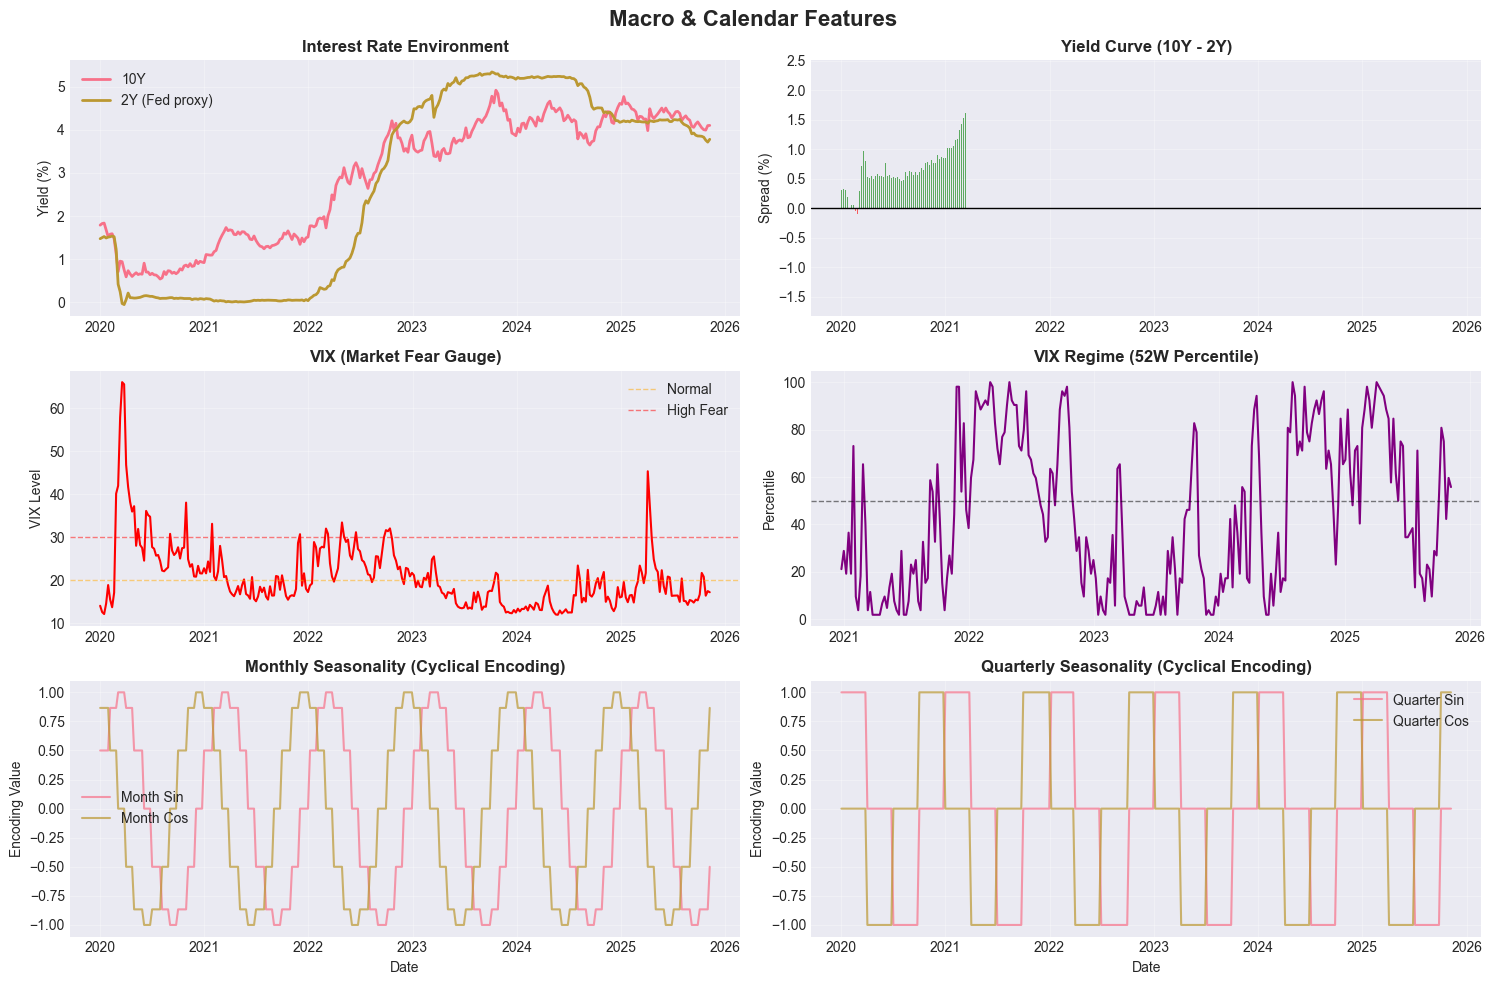

📊 Macro features visualization complete


In [12]:
# Visualize macro features
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Macro & Calendar Features', fontsize=16, fontweight='bold')

# Plot 1: Treasury yields
ax = axes[0, 0]
ax.plot(macro_features.index, macro_features['treasury_10y'], label='10Y', linewidth=2)
ax.plot(macro_features.index, macro_features['fed_funds_rate'], label='2Y (Fed proxy)', linewidth=2)
ax.set_title('Interest Rate Environment', fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Yield curve
ax = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in macro_features['yield_curve_2_10']]
ax.bar(macro_features.index, macro_features['yield_curve_2_10'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Yield Curve (10Y - 2Y)', fontweight='bold')
ax.set_ylabel('Spread (%)')
ax.grid(True, alpha=0.3)

# Plot 3: VIX
ax = axes[1, 0]
ax.plot(macro_features.index, macro_features['vix'], color='red', linewidth=1.5)
ax.axhline(20, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Normal')
ax.axhline(30, color='red', linestyle='--', linewidth=1, alpha=0.5, label='High Fear')
ax.set_title('VIX (Market Fear Gauge)', fontweight='bold')
ax.set_ylabel('VIX Level')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: VIX regime
ax = axes[1, 1]
ax.plot(macro_features.index, macro_features['vix_regime'] * 100, color='purple', linewidth=1.5)
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('VIX Regime (52W Percentile)', fontweight='bold')
ax.set_ylabel('Percentile')
ax.grid(True, alpha=0.3)

# Plot 5: Calendar - Month encoding
ax = axes[2, 0]
ax.plot(macro_features.index, macro_features['month_sin'], label='Month Sin', linewidth=1.5, alpha=0.7)
ax.plot(macro_features.index, macro_features['month_cos'], label='Month Cos', linewidth=1.5, alpha=0.7)
ax.set_title('Monthly Seasonality (Cyclical Encoding)', fontweight='bold')
ax.set_ylabel('Encoding Value')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Calendar - Quarter encoding
ax = axes[2, 1]
ax.plot(macro_features.index, macro_features['quarter_sin'], label='Quarter Sin', linewidth=1.5, alpha=0.7)
ax.plot(macro_features.index, macro_features['quarter_cos'], label='Quarter Cos', linewidth=1.5, alpha=0.7)
ax.set_title('Quarterly Seasonality (Cyclical Encoding)', fontweight='bold')
ax.set_ylabel('Encoding Value')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Macro features visualization complete")

---
## Step 5: Train/Val/Test Splits

**Purpose:** Prevent data leakage and evaluate generalization  
**Method:** Time-based splits (60/20/20) with no shuffling  

**Key Principles:**
- No shuffling (preserves temporal structure)
- No overlap (strict chronological separation)
- Sufficient training size (>200 weeks for RL convergence)

In [13]:
def create_time_splits(df, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2):
    """
    Create time-based train/val/test splits.
    
    Args:
        df: DataFrame with 'date' column
        train_ratio: Training set ratio
        val_ratio: Validation set ratio
        test_ratio: Test set ratio
    
    Returns:
        train_df, val_df, test_df
    """
    # Get unique dates and sort
    unique_dates = sorted(df['date'].unique())
    n_dates = len(unique_dates)
    
    # Calculate split indices
    train_end_idx = int(n_dates * train_ratio)
    val_end_idx = int(n_dates * (train_ratio + val_ratio))
    
    train_dates = unique_dates[:train_end_idx]
    val_dates = unique_dates[train_end_idx:val_end_idx]
    test_dates = unique_dates[val_end_idx:]
    
    # Split data
    train_df = df[df['date'].isin(train_dates)].copy()
    val_df = df[df['date'].isin(val_dates)].copy()
    test_df = df[df['date'].isin(test_dates)].copy()
    
    return train_df, val_df, test_df, (train_dates[0], train_dates[-1]), (val_dates[0], val_dates[-1]), (test_dates[0], test_dates[-1])

# Create splits for each feature set
print("Creating train/val/test splits...\n")

# Technical features
tech_train, tech_val, tech_test, tech_train_range, tech_val_range, tech_test_range = create_time_splits(
    technical_df, TRAIN_RATIO, VAL_RATIO, TEST_RATIO
)
print(f"Technical Features:")
print(f"  Train: {len(tech_train)} rows ({tech_train_range[0].date()} to {tech_train_range[1].date()})")
print(f"  Val:   {len(tech_val)} rows ({tech_val_range[0].date()} to {tech_val_range[1].date()})")
print(f"  Test:  {len(tech_test)} rows ({tech_test_range[0].date()} to {tech_test_range[1].date()})")

# Sentiment features
sent_train, sent_val, sent_test, sent_train_range, sent_val_range, sent_test_range = create_time_splits(
    sentiment_df, TRAIN_RATIO, VAL_RATIO, TEST_RATIO
)
print(f"\nSentiment Features:")
print(f"  Train: {len(sent_train)} rows ({sent_train_range[0].date()} to {sent_train_range[1].date()})")
print(f"  Val:   {len(sent_val)} rows ({sent_val_range[0].date()} to {sent_val_range[1].date()})")
print(f"  Test:  {len(sent_test)} rows ({sent_test_range[0].date()} to {sent_test_range[1].date()})")

# Macro features
macro_train, macro_val, macro_test, macro_train_range, macro_val_range, macro_test_range = create_time_splits(
    macro_df, TRAIN_RATIO, VAL_RATIO, TEST_RATIO
)
print(f"\nMacro Features:")
print(f"  Train: {len(macro_train)} rows ({macro_train_range[0].date()} to {macro_train_range[1].date()})")
print(f"  Val:   {len(macro_val)} rows ({macro_val_range[0].date()} to {macro_val_range[1].date()})")
print(f"  Test:  {len(macro_test)} rows ({macro_test_range[0].date()} to {macro_test_range[1].date()})")

Creating train/val/test splits...

Technical Features:
  Train: 1498 rows (2020-01-03 to 2024-02-02)
  Val:   322 rows (2024-02-09 to 2024-12-20)
  Test:  322 rows (2024-12-27 to 2025-11-07)

Sentiment Features:
  Train: 1498 rows (2020-01-03 to 2024-02-02)
  Val:   322 rows (2024-02-09 to 2024-12-20)
  Test:  322 rows (2024-12-27 to 2025-11-07)

Macro Features:
  Train: 1498 rows (2020-01-03 to 2024-02-02)
  Val:   322 rows (2024-02-09 to 2024-12-20)
  Test:  322 rows (2024-12-27 to 2025-11-07)


In [14]:
# Calculate and split returns
print("\nCalculating weekly returns for each stock...")

returns_df = pd.DataFrame({
    ticker: stock_data_aligned[ticker]['adj_close'].pct_change()
    for ticker in TICKERS
})
returns_df['date'] = common_dates

# Split returns
returns_train, returns_val, returns_test, _, _, _ = create_time_splits(
    returns_df, TRAIN_RATIO, VAL_RATIO, TEST_RATIO
)

print(f"\nReturns Data:")
print(f"  Train: {len(returns_train)} weeks × {len(TICKERS)} stocks")
print(f"  Val:   {len(returns_val)} weeks × {len(TICKERS)} stocks")
print(f"  Test:  {len(returns_test)} weeks × {len(TICKERS)} stocks")


Calculating weekly returns for each stock...

Returns Data:
  Train: 214 weeks × 7 stocks
  Val:   46 weeks × 7 stocks
  Test:  46 weeks × 7 stocks


## Step 5.5: Fill Null Values

**Purpose:** Fill null values from rolling features before normalization  
**Method:** Forward fill → Backward fill → Zero fill  

**Why Nulls Exist:**
- Rolling features (52-week) need warmup periods
- Early data points don't have enough history
- Strategy: Forward fill (use last valid), then backward fill, finally zero for any remaining

In [15]:
print("Filling null values before normalization...")
print(f"Initial null counts:")
print(f"  Technical: {tech_train.isnull().sum().sum()} nulls")
print(f"  Sentiment: {sent_train.isnull().sum().sum()} nulls")
print(f"  Macro: {macro_train.isnull().sum().sum()} nulls")

# Identify feature columns
feature_cols_tech = [col for col in tech_train.columns if col not in ['date', 'ticker']]
feature_cols_sent = [col for col in sent_train.columns if col not in ['date', 'ticker']]
feature_cols_macro = [col for col in macro_train.columns if col not in ['date', 'ticker']]

# Fill nulls: forward fill → backward fill → zeros
for df in [tech_train, tech_val, tech_test]:
    df[feature_cols_tech] = df[feature_cols_tech].ffill().bfill().fillna(0)

for df in [sent_train, sent_val, sent_test]:
    df[feature_cols_sent] = df[feature_cols_sent].ffill().bfill().fillna(0)

for df in [macro_train, macro_val, macro_test]:
    df[feature_cols_macro] = df[feature_cols_macro].ffill().bfill().fillna(0)

print(f"\n✅ Nulls filled successfully!")
print(f"Final null counts:")
print(f"  Technical: {tech_train.isnull().sum().sum()} nulls")
print(f"  Sentiment: {sent_train.isnull().sum().sum()} nulls")
print(f"  Macro: {macro_train.isnull().sum().sum()} nulls")

Filling null values before normalization...
Initial null counts:
  Technical: 1155 nulls
  Sentiment: 1449 nulls
  Macro: 714 nulls

✅ Nulls filled successfully!
Final null counts:
  Technical: 0 nulls
  Sentiment: 0 nulls
  Macro: 0 nulls


---
## Step 6: Feature Normalization

**Purpose:** Prevent data leakage and ensure stable RL training  
**Method:** StandardScaler (z-score normalization)  

**Critical:** Fit scaler on training data ONLY, then transform all splits using training statistics

In [16]:
def normalize_features(train_df, val_df, test_df, exclude_cols=['date', 'ticker']):
    """
    Normalize features using StandardScaler (fit on train only).
    
    Args:
        train_df: Training DataFrame
        val_df: Validation DataFrame
        test_df: Test DataFrame
        exclude_cols: Columns to exclude from normalization
    
    Returns:
        train_normalized, val_normalized, test_normalized, scaler, feature_cols
    """
    # Identify feature columns
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    # Fit scaler on training data
    scaler = StandardScaler()
    train_features_normalized = scaler.fit_transform(train_df[feature_cols])
    
    # Transform val and test using training statistics
    val_features_normalized = scaler.transform(val_df[feature_cols])
    test_features_normalized = scaler.transform(test_df[feature_cols])
    
    # Create normalized DataFrames
    train_normalized = pd.DataFrame(
        train_features_normalized, 
        columns=feature_cols,
        index=train_df.index
    )
    train_normalized['date'] = train_df['date'].values
    train_normalized['ticker'] = train_df['ticker'].values
    
    val_normalized = pd.DataFrame(
        val_features_normalized,
        columns=feature_cols,
        index=val_df.index
    )
    val_normalized['date'] = val_df['date'].values
    val_normalized['ticker'] = val_df['ticker'].values
    
    test_normalized = pd.DataFrame(
        test_features_normalized,
        columns=feature_cols,
        index=test_df.index
    )
    test_normalized['date'] = test_df['date'].values
    test_normalized['ticker'] = test_df['ticker'].values
    
    return train_normalized, val_normalized, test_normalized, scaler, feature_cols

# Normalize all feature sets
print("Normalizing features (fit on train only)...\n")

tech_train_norm, tech_val_norm, tech_test_norm, tech_scaler, tech_feature_cols = normalize_features(
    tech_train, tech_val, tech_test
)
print(f"✅ Technical features normalized: {len(tech_feature_cols)} features")

sent_train_norm, sent_val_norm, sent_test_norm, sent_scaler, sent_feature_cols = normalize_features(
    sent_train, sent_val, sent_test
)
print(f"✅ Sentiment features normalized: {len(sent_feature_cols)} features")

macro_train_norm, macro_val_norm, macro_test_norm, macro_scaler, macro_feature_cols = normalize_features(
    macro_train, macro_val, macro_test
)
print(f"✅ Macro features normalized: {len(macro_feature_cols)} features")

Normalizing features (fit on train only)...

✅ Technical features normalized: 20 features
✅ Sentiment features normalized: 12 features
✅ Macro features normalized: 12 features


In [17]:
# Validation: Check normalization worked correctly
print("\nValidation: Training set normalization statistics")
print("="*60)

for name, df, cols in [
    ('Technical', tech_train_norm, tech_feature_cols),
    ('Sentiment', sent_train_norm, sent_feature_cols),
    ('Macro', macro_train_norm, macro_feature_cols)
]:
    means = df[cols].mean()
    stds = df[cols].std()
    print(f"\n{name} Features:")
    print(f"  Mean range: [{means.min():.4f}, {means.max():.4f}] (should be near 0)")
    print(f"  Std range:  [{stds.min():.4f}, {stds.max():.4f}] (should be near 1)")


Validation: Training set normalization statistics

Technical Features:
  Mean range: [-0.0000, 0.0000] (should be near 0)
  Std range:  [1.0003, 1.0003] (should be near 1)

Sentiment Features:
  Mean range: [-0.0000, 0.0000] (should be near 0)
  Std range:  [1.0003, 1.0003] (should be near 1)

Macro Features:
  Mean range: [-0.0000, 0.0000] (should be near 0)
  Std range:  [0.0000, 1.0003] (should be near 1)


In [18]:
# Save all normalized features to CSV
print("Saving data to CSV files...\n")

# Technical features
tech_train_norm.to_csv(DATA_DIR / 'technical' / 'train.csv', index=False)
tech_val_norm.to_csv(DATA_DIR / 'technical' / 'val.csv', index=False)
tech_test_norm.to_csv(DATA_DIR / 'technical' / 'test.csv', index=False)
print(f"✅ Technical features saved:")
print(f"   {DATA_DIR / 'technical' / 'train.csv'} ({len(tech_train_norm)} rows)")
print(f"   {DATA_DIR / 'technical' / 'val.csv'} ({len(tech_val_norm)} rows)")
print(f"   {DATA_DIR / 'technical' / 'test.csv'} ({len(tech_test_norm)} rows)")

# Sentiment features
sent_train_norm.to_csv(DATA_DIR / 'sentiment' / 'train.csv', index=False)
sent_val_norm.to_csv(DATA_DIR / 'sentiment' / 'val.csv', index=False)
sent_test_norm.to_csv(DATA_DIR / 'sentiment' / 'test.csv', index=False)
print(f"\n✅ Sentiment features saved:")
print(f"   {DATA_DIR / 'sentiment' / 'train.csv'} ({len(sent_train_norm)} rows)")
print(f"   {DATA_DIR / 'sentiment' / 'val.csv'} ({len(sent_val_norm)} rows)")
print(f"   {DATA_DIR / 'sentiment' / 'test.csv'} ({len(sent_test_norm)} rows)")

# Macro features
macro_train_norm.to_csv(DATA_DIR / 'macro' / 'train.csv', index=False)
macro_val_norm.to_csv(DATA_DIR / 'macro' / 'val.csv', index=False)
macro_test_norm.to_csv(DATA_DIR / 'macro' / 'test.csv', index=False)
print(f"\n✅ Macro features saved:")
print(f"   {DATA_DIR / 'macro' / 'train.csv'} ({len(macro_train_norm)} rows)")
print(f"   {DATA_DIR / 'macro' / 'val.csv'} ({len(macro_val_norm)} rows)")
print(f"   {DATA_DIR / 'macro' / 'test.csv'} ({len(macro_test_norm)} rows)")

# Returns data
returns_train.to_csv(DATA_DIR / 'returns_train.csv', index=False)
returns_val.to_csv(DATA_DIR / 'returns_val.csv', index=False)
returns_test.to_csv(DATA_DIR / 'returns_test.csv', index=False)
print(f"\n✅ Returns data saved:")
print(f"   {DATA_DIR / 'returns_train.csv'} ({len(returns_train)} weeks)")
print(f"   {DATA_DIR / 'returns_val.csv'} ({len(returns_val)} weeks)")
print(f"   {DATA_DIR / 'returns_test.csv'} ({len(returns_test)} weeks)")

print(f"\n✅ All data files saved successfully!")

Saving data to CSV files...

✅ Technical features saved:
   ../data_hierarchical/technical/train.csv (1498 rows)
   ../data_hierarchical/technical/val.csv (322 rows)
   ../data_hierarchical/technical/test.csv (322 rows)

✅ Sentiment features saved:
   ../data_hierarchical/sentiment/train.csv (1498 rows)
   ../data_hierarchical/sentiment/val.csv (322 rows)
   ../data_hierarchical/sentiment/test.csv (322 rows)

✅ Macro features saved:
   ../data_hierarchical/macro/train.csv (1498 rows)
   ../data_hierarchical/macro/val.csv (322 rows)
   ../data_hierarchical/macro/test.csv (322 rows)

✅ Returns data saved:
   ../data_hierarchical/returns_train.csv (214 weeks)
   ../data_hierarchical/returns_val.csv (46 weeks)
   ../data_hierarchical/returns_test.csv (46 weeks)

✅ All data files saved successfully!


---
## Step 7: Save & Validate

**Purpose:** Create production-ready datasets with complete metadata  

**Outputs:**
- CSV files for each agent (train/val/test)
- Returns data (train/val/test)
- Metadata JSON with normalization parameters

In [19]:
# Create metadata
metadata = {
    'tickers': TICKERS,
    'benchmark': BENCHMARK,
    'date_range': {
        'start': str(common_dates[0].date()),
        'end': str(common_dates[-1].date()),
        'total_weeks': len(common_dates)
    },
    'splits': {
        'train': {
            'ratio': TRAIN_RATIO,
            'start': str(tech_train_range[0].date()),
            'end': str(tech_train_range[1].date()),
            'weeks': len(tech_train) // len(TICKERS)
        },
        'val': {
            'ratio': VAL_RATIO,
            'start': str(tech_val_range[0].date()),
            'end': str(tech_val_range[1].date()),
            'weeks': len(tech_val) // len(TICKERS)
        },
        'test': {
            'ratio': TEST_RATIO,
            'start': str(tech_test_range[0].date()),
            'end': str(tech_test_range[1].date()),
            'weeks': len(tech_test) // len(TICKERS)
        }
    },
    'features': {
        'technical': {
            'count': len(tech_feature_cols),
            'names': tech_feature_cols
        },
        'sentiment': {
            'count': len(sent_feature_cols),
            'names': sent_feature_cols
        },
        'macro': {
            'count': len(macro_feature_cols),
            'names': macro_feature_cols
        }
    },
    'normalization': {
        'technical': {
            'means': tech_scaler.mean_.tolist(),
            'stds': tech_scaler.scale_.tolist(),
            'feature_list': tech_feature_cols
        },
        'sentiment': {
            'means': sent_scaler.mean_.tolist(),
            'stds': sent_scaler.scale_.tolist(),
            'feature_list': sent_feature_cols
        },
        'macro': {
            'means': macro_scaler.mean_.tolist(),
            'stds': macro_scaler.scale_.tolist(),
            'feature_list': macro_feature_cols
        }
    },
    'created_at': datetime.now().isoformat()
}

# Save metadata
with open(DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Metadata saved to metadata.json")


✅ Metadata saved to metadata.json


In [20]:
# Final validation checks
print("\n" + "="*70)
print("FINAL VALIDATION CHECKS")
print("="*70)

all_checks_passed = True

# Check 1: No null values (after warmup period)
for name, df in [
    ('Technical Train', tech_train_norm),
    ('Sentiment Train', sent_train_norm),
    ('Macro Train', macro_train_norm)
]:
    # Skip first 52 weeks (warmup for rolling calculations)
    df_after_warmup = df.iloc[52*len(TICKERS):]
    null_count = df_after_warmup.isnull().sum().sum()
    if null_count == 0:
        print(f"✅ {name}: No null values after warmup")
    else:
        print(f"❌ {name}: {null_count} null values found!")
        all_checks_passed = False

# Check 2: No infinite values
for name, df in [
    ('Technical Train', tech_train_norm),
    ('Sentiment Train', sent_train_norm),
    ('Macro Train', macro_train_norm)
]:
    inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    if inf_count == 0:
        print(f"✅ {name}: No infinite values")
    else:
        print(f"❌ {name}: {inf_count} infinite values found!")
        all_checks_passed = False

# Check 3: All tickers present in all periods
for name, df in [
    ('Technical', tech_train_norm),
    ('Sentiment', sent_train_norm),
    ('Macro', macro_train_norm)
]:
    unique_tickers = df['ticker'].unique()
    if set(unique_tickers) == set(TICKERS):
        print(f"✅ {name}: All {len(TICKERS)} tickers present")
    else:
        print(f"❌ {name}: Missing tickers! Found {unique_tickers}")
        all_checks_passed = False

# Check 4: Feature counts match specifications
expected_counts = {'Technical': 20, 'Sentiment': 12, 'Macro': 12}
actual_counts = {
    'Technical': len(tech_feature_cols),
    'Sentiment': len(sent_feature_cols),
    'Macro': len(macro_feature_cols)
}

for name, expected in expected_counts.items():
    actual = actual_counts[name]
    if actual == expected:
        print(f"✅ {name}: {actual} features (matches specification)")
    else:
        print(f"❌ {name}: {actual} features (expected {expected})!")
        all_checks_passed = False

print("\n" + "="*70)
if all_checks_passed:
    print("🎉 ALL VALIDATION CHECKS PASSED!")
else:
    print("⚠️  SOME VALIDATION CHECKS FAILED - REVIEW ABOVE")
print("="*70)


FINAL VALIDATION CHECKS
✅ Technical Train: No null values after warmup
✅ Sentiment Train: No null values after warmup
✅ Macro Train: No null values after warmup
✅ Technical Train: No infinite values
✅ Sentiment Train: No infinite values
✅ Macro Train: No infinite values
✅ Technical: All 7 tickers present
✅ Sentiment: All 7 tickers present
✅ Macro: All 7 tickers present
✅ Technical: 20 features (matches specification)
✅ Sentiment: 12 features (matches specification)
✅ Macro: 12 features (matches specification)

🎉 ALL VALIDATION CHECKS PASSED!


In [21]:
# Summary statistics
print("\n" + "="*70)
print("DATA PREPARATION SUMMARY")
print("="*70)

print(f"\n📊 Portfolio Configuration:")
print(f"   Stocks: {', '.join(TICKERS)}")
print(f"   Benchmark: {BENCHMARK}")
print(f"   Total Weeks: {len(common_dates)}")
print(f"   Date Range: {common_dates[0].date()} to {common_dates[-1].date()}")

print(f"\n📈 Feature Engineering:")
print(f"   Technical Agent: {len(tech_feature_cols)} features")
print(f"   Sentiment Agent: {len(sent_feature_cols)} features")
print(f"   Macro Agent: {len(macro_feature_cols)} features")
print(f"   Total Features: {sum([len(tech_feature_cols), len(sent_feature_cols), len(macro_feature_cols)])}")

print(f"\n🔀 Data Splits:")
print(f"   Train: {metadata['splits']['train']['weeks']} weeks ({TRAIN_RATIO*100:.0f}%)")
print(f"   Val:   {metadata['splits']['val']['weeks']} weeks ({VAL_RATIO*100:.0f}%)")
print(f"   Test:  {metadata['splits']['test']['weeks']} weeks ({TEST_RATIO*100:.0f}%)")

print(f"\n💾 Output Files:")
print(f"   {DATA_DIR / 'technical'}/ (train.csv, val.csv, test.csv)")
print(f"   {DATA_DIR / 'sentiment'}/ (train.csv, val.csv, test.csv)")
print(f"   {DATA_DIR / 'macro'}/ (train.csv, val.csv, test.csv)")
print(f"   {DATA_DIR}/ (returns_*.csv, metadata.json)")

print(f"\n✅ Data preparation complete! Ready for agent training.")
print("="*70)


DATA PREPARATION SUMMARY

📊 Portfolio Configuration:
   Stocks: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
   Benchmark: QQQ
   Total Weeks: 306
   Date Range: 2020-01-03 to 2025-11-07

📈 Feature Engineering:
   Technical Agent: 20 features
   Sentiment Agent: 12 features
   Macro Agent: 12 features
   Total Features: 44

🔀 Data Splits:
   Train: 214 weeks (70%)
   Val:   46 weeks (15%)
   Test:  46 weeks (15%)

💾 Output Files:
   ../data_hierarchical/technical/ (train.csv, val.csv, test.csv)
   ../data_hierarchical/sentiment/ (train.csv, val.csv, test.csv)
   ../data_hierarchical/macro/ (train.csv, val.csv, test.csv)
   ../data_hierarchical/ (returns_*.csv, metadata.json)

✅ Data preparation complete! Ready for agent training.
